# Iterative Closest Point Algorithm

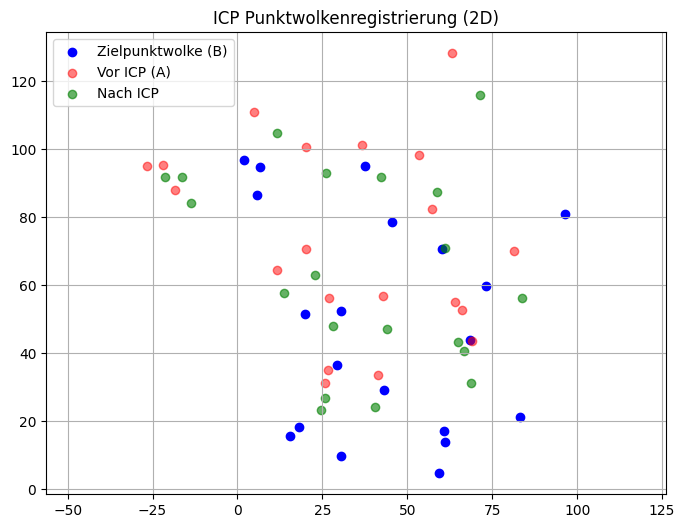

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

def best_fit_transform(A, B):
    """Berechne optimale Rotation R und Translation t, sodass R*A + t ≈ B"""
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)

    AA = A - centroid_A
    BB = B - centroid_B

    H = AA.T @ BB
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = centroid_B - R @ centroid_A

    return R, t

def icp(A, B, max_iterations=20, tolerance=1e-5):
    """Iterative Closest Point Algorithmus"""
    src = A.copy()
    dst = B.copy()

    prev_error = float('inf')

    for i in range(max_iterations):
        # Finde nächstgelegene Punkte
        tree = cKDTree(dst)
        distances, indices = tree.query(src)

        # Berechne optimale Transformation
        R, t = best_fit_transform(src, dst[indices])

        # Transformiere Quellpunkte
        src = (R @ src.T).T + t

        # Abbruchbedingung
        mean_error = np.mean(distances)
        if abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error

    return R, t, src

# Beispielpunktwolken
np.random.seed(42)
B = np.random.rand(20, 2) * 100  # Zielpunktwolke
angle = np.deg2rad(30)
R_true = np.array([[np.cos(angle), -np.sin(angle)],
                   [np.sin(angle),  np.cos(angle)]])
t_true = np.array([20, 10])
A = (R_true @ B.T).T + t_true + np.random.normal(0, 0.002, B.shape)  # verschoben + verrauscht

# ICP
R_est, t_est, A_aligned = icp(A, B)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(B[:, 0], B[:, 1], c='blue', label='Zielpunktwolke (B)')
plt.scatter(A[:, 0], A[:, 1], c='red', alpha=0.5, label='Vor ICP (A)')
plt.scatter(A_aligned[:, 0], A_aligned[:, 1], c='green', alpha=0.6, label='Nach ICP')
plt.legend()
plt.title("ICP Punktwolkenregistrierung (2D)")
plt.axis('equal')
plt.grid(True)
plt.show()

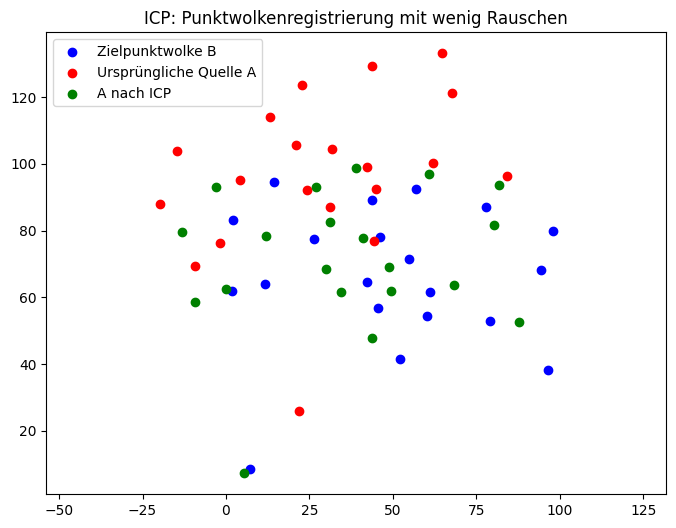

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Generiere Zielpunktwolke B
np.random.seed(0)
B = np.random.rand(20, 2) * 100

# Definiere wahre Transformation (Rotation + Translation)
theta = np.deg2rad(30)
R_true = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])
t_true = np.array([20, 15])

# Erzeuge transformierte Quelle A mit WENIGER Rauschen
A = (R_true @ B.T).T + t_true + np.random.normal(0, 0.002, B.shape)

# ICP-Algorithmus
def icp(A, B, max_iter=50, tol=1e-6):
    src = A.copy()
    prev_error = float('inf')

    for _ in range(max_iter):
        tree = cKDTree(B)
        distances, indices = tree.query(src)
        matched_B = B[indices]

        # Zentriere Punktwolken
        centroid_A = np.mean(src, axis=0)
        centroid_B = np.mean(matched_B, axis=0)
        AA = src - centroid_A
        BB = matched_B - centroid_B

        # Bestimme Rotation
        H = AA.T @ BB
        U, _, VT = np.linalg.svd(H)
        R = VT.T @ U.T

        # Spiegele ggf. zurück
        if np.linalg.det(R) < 0:
            VT[1, :] *= -1
            R = VT.T @ U.T

        t = centroid_B - R @ centroid_A

        # Transformiere Quelle
        src = (R @ src.T).T + t

        # Abbruchbedingung
        mean_error = np.mean(distances)
        if abs(prev_error - mean_error) < tol:
            break
        prev_error = mean_error

    return R, t, src

# Führe ICP durch
R_est, t_est, A_aligned = icp(A, B)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(B[:, 0], B[:, 1], c='blue', label='Zielpunktwolke B')
plt.scatter(A[:, 0], A[:, 1], c='red', label='Ursprüngliche Quelle A')
plt.scatter(A_aligned[:, 0], A_aligned[:, 1], c='green', label='A nach ICP')
plt.legend()
plt.axis('equal')
plt.title('ICP: Punktwolkenregistrierung mit wenig Rauschen')
plt.show()

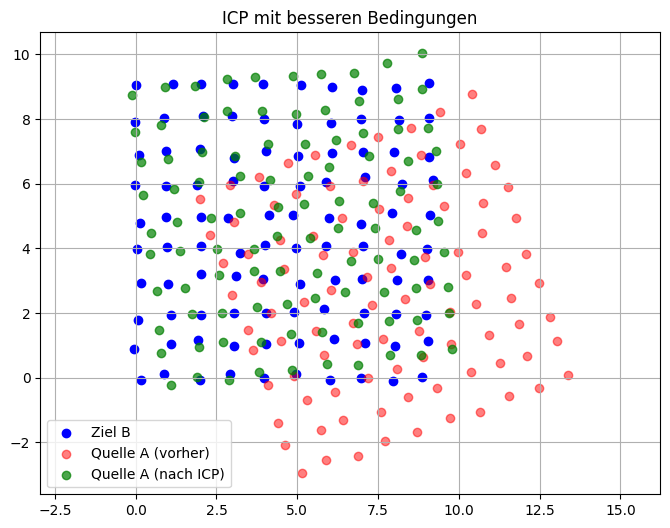

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

np.random.seed(1)

# Erzeuge Zielpunktwolke (z. B. ein Quadratgitter mit leichtem Rauschen)
B = np.array([[x, y] for x in range(10) for y in range(10)]) + np.random.normal(0, 0.1, (100, 2))

# Transformation
theta = np.deg2rad(20)
R_true = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])
t_true = np.array([5, -3])

# Quelle erzeugen (rotierte + verschobene Punktwolke + wenig Rauschen)
A = (R_true @ B.T).T + t_true + np.random.normal(0, 0.05, B.shape)

def icp(A, B, max_iter=50, tol=1e-6, max_corresp_dist=None):
    src = A.copy()
    prev_error = float('inf')

    for _ in range(max_iter):
        tree = cKDTree(B)
        distances, indices = tree.query(src)

        if max_corresp_dist is not None:
            mask = distances < max_corresp_dist
            src_valid = src[mask]
            matched_B = B[indices[mask]]
        else:
            src_valid = src
            matched_B = B[indices]

        # Zentriere
        centroid_A = np.mean(src_valid, axis=0)
        centroid_B = np.mean(matched_B, axis=0)
        AA = src_valid - centroid_A
        BB = matched_B - centroid_B

        H = AA.T @ BB
        U, _, VT = np.linalg.svd(H)
        R = VT.T @ U.T

        if np.linalg.det(R) < 0:
            VT[1, :] *= -1
            R = VT.T @ U.T

        t = centroid_B - R @ centroid_A

        # Update Quelle
        src = (R @ src.T).T + t

        # Fehler prüfen
        mean_error = np.mean(distances)
        if abs(prev_error - mean_error) < tol:
            break
        prev_error = mean_error

    return R, t, src

# ICP starten
R_est, t_est, A_aligned = icp(A, B, max_corresp_dist=2.0)

# Plotten
plt.figure(figsize=(8, 6))
plt.scatter(B[:, 0], B[:, 1], label='Ziel B', c='blue')
plt.scatter(A[:, 0], A[:, 1], label='Quelle A (vorher)', c='red', alpha=0.5)
plt.scatter(A_aligned[:, 0], A_aligned[:, 1], label='Quelle A (nach ICP)', c='green', alpha=0.7)
plt.legend()
plt.axis('equal')
plt.title('ICP mit besseren Bedingungen')
plt.grid(True)
plt.show()